# Statistical significance of the four paper metrics

This notebook analyzes **speaker-centroid cosine distance, median radial distance, q90 radial distance, and participation ratio**. Each observation is one conversation; conversations are grouped by video (shared topic and explaining expert).

For each outcome, fit two Gaussian random-intercept models:

- **Unadjusted:** `metric ~ partner expertise + (1 | video)`
- **Utterance-count adjusted:** `metric ~ partner expertise + log(n_utterances) + (1 | video)`

Expertise is scored child = 0 through expert = 4. A positive coefficient means a larger metric at higher partner expertise. This is an equal-step linear trend assumption, not a claim that educational categories are equally spaced measurements of skill. Models estimate associations, not causal effects.

Run all cells from the project root or this notebook's directory. No embedding downloads or previous notebook execution are needed if the static export exists. Outputs are written to `outputs/paper/statistical_significance/`.

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from IPython.display import display

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p / "data/wired").is_dir() and (p / "paper").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run from this repository or one of its notebook directories.")
SOURCE = PROJECT_ROOT / "outputs/paper/conversation_metrics.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs/paper/statistical_significance"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 20260913
N_BOOTSTRAP = 999  # Increase to 4999+ for final reporting; runtime grows proportionally.
ALPHA = 0.05
METRICS = {
    "speaker_centroid_cosine_distance": "Speaker-centroid distance",
    "radial_distance_median": "Median radial distance",
    "radial_distance_q90": "Q90 radial distance",
    "participation_ratio": "Participation ratio (ordinary)",
}
LEVELS = ["child", "teenager", "undergraduate", "graduate", "expert"]
pd.set_option("display.max_columns", 30)
print("Source:", SOURCE)
print("Bootstrap replicates per test:", N_BOOTSTRAP)
# Shared project plotting conventions.
import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from plot_style import (
    apply_style, expertise_palette, EXPERTISE_COLORS, LEVEL_LABELS,
    METRIC_LABELS, MODEL_COLORS, MODEL_MARKERS, PRIMARY, NEUTRAL,
    plot_metric_trajectories, save_figure,
)
apply_style()


Source: /Users/yume/PycharmProjects/horizons_2/outputs/paper/conversation_metrics.csv
Bootstrap replicates per test: 999


## Metric provenance and sample audit

Run notebook 01 first to create `outputs/paper/conversation_metrics.csv`. Radial metrics and PR use all nonempty utterances; speaker-centroid distance uses utterances of at least five words. The count covariate is the total count, not the centroid subset size. This preserves the prior definitions explicitly.

All four outcomes come from the same static geometry export produced by `01_static_geometric_metrics.ipynb`:

| Outcome | Definition |
|---|---|
| Speaker-centroid distance | Cosine distance between the expert and partner mean embedding vectors |
| Median radial distance | Median cosine distance of utterances from the normalized pooled conversation centroid |
| Q90 radial distance | 90th percentile of those same radial distances |
| Participation ratio | Ordinary centered-covariance PR: `(sum eigenvalues)^2 / sum(eigenvalues^2)` |

**PR here is not the row-bias-corrected PR from notebook 03.** The saved microdynamics table has different utterance counts and fewer conversations, so it is not silently joined to these outcomes. If the paper uses corrected PR, export it from the same utterance selection and deliberately update this notebook's source and metric definition before reporting its results. Likewise, these radial metrics use the full centroid, not the later leave-one-out variant.

Use the same complete-case sample in all eight fits so that adjusted/unadjusted differences do not reflect changes in sample membership. Exclusions are displayed and saved. The source currently contains 21 complete video sets (105 conversations); the notebook audits rather than hard-codes that count.

In [2]:
if not SOURCE.exists():
    raise FileNotFoundError("Run notebooks/paper/01_static_geometric_metrics.ipynb first.")
raw = pd.read_csv(SOURCE)
required = ["dataset", "conversation_id", "video_id", "level", "level_label", "n_utterances", *METRICS]
missing = set(required) - set(raw.columns)
if missing:
    raise ValueError(f"Missing source columns: {missing}")
if raw.duplicated(["dataset", "conversation_id"]).any():
    raise ValueError("Duplicate conversation IDs in source.")
for col in ["level", "n_utterances", *METRICS]:
    raw[col] = pd.to_numeric(raw[col], errors="raise")
valid = raw[required].notna().all(axis=1)
valid &= np.isfinite(raw[["level", "n_utterances", *METRICS]]).all(axis=1)
valid &= raw["n_utterances"].gt(1)
excluded = raw.loc[~valid, required].copy()
data = raw.loc[valid, required].copy()
data["video_group"] = data["dataset"].astype(str) + "::" + data["video_id"].astype(str)
if not data["level"].isin(range(5)).all():
    raise ValueError("Expected expertise levels 0 through 4.")
if not data["level_label"].eq(data["level"].map(dict(enumerate(LEVELS)))).all():
    raise ValueError("Expertise labels disagree with scores.")
if data.duplicated(["video_group", "level"]).any():
    raise ValueError("Expected at most one conversation per video and expertise level.")
data["expertise_c"] = data["level"] - 2.0
data["log_n_c"] = np.log(data["n_utterances"]) - np.log(data["n_utterances"]).mean()
data = data.sort_values(["video_group", "level"]).reset_index(drop=True)
if data["video_group"].nunique() < 5 or len(data) < 15:
    raise ValueError("Too few observations/groups for this analysis plan.")
for metric in METRICS:
    if data[metric].std(ddof=1) <= 0:
        raise ValueError(f"Constant outcome: {metric}")
coverage = pd.crosstab(data["video_group"], data["level_label"]).reindex(columns=LEVELS, fill_value=0)
print(f"Included {len(data)} conversations in {data.video_group.nunique()} videos; excluded {len(excluded)} rows.")
display(coverage)
if not coverage.eq(1).all().all():
    warnings.warn("Incomplete matched video sets: inspect coverage and exclusions before interpretation.")
if len(excluded):
    display(excluded)
display(data.groupby("level_label")["n_utterances"].agg(["count", "median", "min", "max"]).reindex(LEVELS))
excluded.to_csv(OUTPUT_DIR / "excluded_conversations.csv", index=False)
data.to_csv(OUTPUT_DIR / "analysis_data.csv", index=False)
coverage.to_csv(OUTPUT_DIR / "video_level_coverage.csv")

Included 105 conversations in 21 videos; excluded 0 rows.


level_label,child,teenager,undergraduate,graduate,expert
video_group,,,,,
wired::astro,1,1,1,1,1
wired::blockchain,1,1,1,1,1
wired::crispr,1,1,1,1,1
wired::dimension,1,1,1,1,1
wired::fractal,1,1,1,1,1
wired::gravity,1,1,1,1,1
wired::hacking,1,1,1,1,1
wired::infinity,1,1,1,1,1
wired::internet,1,1,1,1,1


,count,median,min,max
level_label,,,,
child,21,56.0,12,93
teenager,21,58.0,13,116
undergraduate,21,57.0,20,117
graduate,21,53.0,16,103
expert,21,68.0,23,151


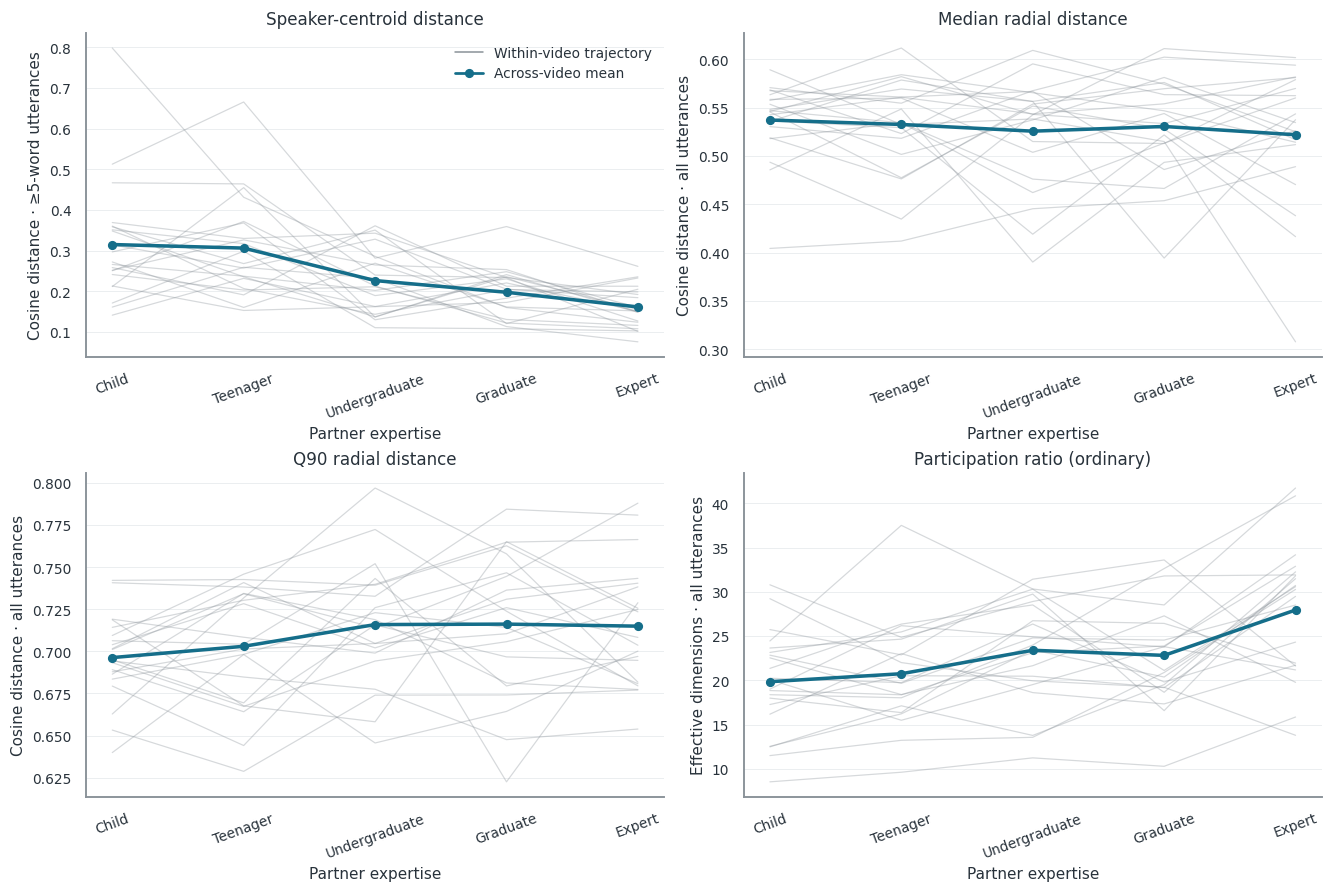

In [3]:
fig, axes = plot_metric_trajectories(data)
save_figure(fig, OUTPUT_DIR / "within_video_trajectories.png")
plt.show()

## Fit the multilevel models

Fixed effects and variance components below are fitted using **REML**. Outcomes are standardized once across the common sample for comparable plots; raw-unit effects are also retained. Utterance count enters as a centered natural logarithm. The adjusted coefficient describes comparisons at equal utterance count; the unadjusted coefficient includes differences associated with length.

The random intercept absorbs video-level baseline variation. This model assumes a common expertise slope and conditionally independent, constant-variance Gaussian conversation residuals. It does not separately identify topic and focal-expert effects. With one observation per conversation, there is no additional conversation random intercept.

Warnings, convergence and near-zero random-intercept variance are recorded. Boundary fits are not automatically discarded. Bootstrap testing below uses the same random-intercept assumptions; it does not cure an incorrect covariance structure.

In [4]:
def fit_reml(frame, formula):
    candidates = []
    messages = []
    for method in ("lbfgs", "powell"):
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            try:
                result = smf.mixedlm(formula, frame, groups=frame["video_group"], re_formula="1").fit(
                    reml=True, method=method, maxiter=1500, disp=False)
                if result.converged and np.isfinite(result.llf) and np.isfinite(result.bse_fe).all():
                    candidates.append(result)
            except (ValueError, np.linalg.LinAlgError) as exc:
                messages.append(f"{method}: {exc}")
            messages.extend(f"{method}: {w.message}" for w in caught)
    if not candidates:
        raise RuntimeError(f"No usable converged REML fit for {formula}: {messages}")
    result = max(candidates, key=lambda fit: fit.llf)
    return result, " | ".join(dict.fromkeys(messages))

fits, frames, records = {}, {}, []
for metric, label in METRICS.items():
    frame = data.copy()
    outcome_sd = frame[metric].std(ddof=1)
    frame["outcome_z"] = (frame[metric] - frame[metric].mean()) / outcome_sd
    frames[metric] = frame
    for adjustment, formula in {
        "Unadjusted": "outcome_z ~ expertise_c",
        "Count-adjusted": "outcome_z ~ expertise_c + log_n_c",
    }.items():
        result, fit_warnings = fit_reml(frame, formula)
        fits[(metric, adjustment)] = result
        beta = result.fe_params["expertise_c"]
        lo, hi = result.conf_int().loc["expertise_c"]
        video_var = float(np.asarray(result.cov_re)[0, 0])
        records.append(dict(metric=metric, label=label, adjustment=adjustment,
            n_conversations=len(frame), n_videos=frame.video_group.nunique(),
            beta_sd=beta, se_sd=result.bse_fe["expertise_c"], ci_low_sd=lo, ci_high_sd=hi,
            beta_raw=beta*outcome_sd, ci_low_raw=lo*outcome_sd, ci_high_raw=hi*outcome_sd,
            expert_minus_child_raw=4*beta*outcome_sd,
            expert_minus_child_low_raw=4*lo*outcome_sd, expert_minus_child_high_raw=4*hi*outcome_sd,
            p_wald_asymptotic=result.pvalues["expertise_c"],
            log_count_beta_sd=result.fe_params.get("log_n_c", np.nan),
            video_variance=video_var, residual_variance=result.scale,
            icc=video_var/(video_var+result.scale),
            boundary_variance=video_var < 1e-6*result.scale,
            converged=result.converged, fit_warnings=fit_warnings))
results = pd.DataFrame(records)
display(results[["label", "adjustment", "beta_raw", "ci_low_raw", "ci_high_raw", "icc", "boundary_variance", "converged"]])
for row in records:
    if row["fit_warnings"]:
        print(row["label"], row["adjustment"], row["fit_warnings"])

,label,adjustment,beta_raw,ci_low_raw,ci_high_raw,icc,boundary_variance,converged
0,Speaker-centroid distance,Unadjusted,-0.041560,-0.053085,-0.030034,0.250118,False,True
1,Speaker-centroid distance,Count-adjusted,-0.035646,-0.047179,-0.024112,0.025771,False,True
2,Median radial distance,Unadjusted,-0.003251,-0.009733,0.003232,0.206927,False,True
3,Median radial distance,Count-adjusted,-0.007130,-0.012833,-0.001428,0.133443,False,True
4,Q90 radial distance,Unadjusted,0.005050,0.001209,0.008892,0.357830,False,True
5,Q90 radial distance,Count-adjusted,0.003785,-0.000099,0.007669,0.304151,False,True
6,Participation ratio (ordinary),Unadjusted,1.826757,1.192640,2.460873,0.426304,False,True
7,Participation ratio (ordinary),Count-adjusted,1.169258,0.789843,1.548674,0.428294,False,True


Speaker-centroid distance Unadjusted lbfgs: Random effects covariance is singular
Speaker-centroid distance Count-adjusted lbfgs: Random effects covariance is singular | lbfgs: The MLE may be on the boundary of the parameter space.
Median radial distance Unadjusted lbfgs: Random effects covariance is singular
Median radial distance Count-adjusted lbfgs: Random effects covariance is singular | lbfgs: The MLE may be on the boundary of the parameter space.
Q90 radial distance Unadjusted lbfgs: Random effects covariance is singular
Q90 radial distance Count-adjusted lbfgs: Random effects covariance is singular
Participation ratio (ordinary) Unadjusted lbfgs: Random effects covariance is singular
Participation ratio (ordinary) Count-adjusted lbfgs: Random effects covariance is singular


## Parametric-bootstrap significance tests

For each model, test the null that the **linear expertise coefficient is zero**, retaining the count covariate in the adjusted null. Fit null and full models using **maximum likelihood**, simulate whole video random intercepts and conversation residuals under the fitted null, refit both models, and compare likelihood-ratio statistics. Never compare REML likelihoods with different fixed effects.

To make 8 × 999 simulations practical, the helper profiles the exact Gaussian random-intercept likelihood. It uses `V = sigma² (I + r ZZᵀ)`, profiles GLS coefficients and residual variance, and optimizes the nonnegative variance ratio `r`. The zero-variance boundary is considered explicitly. Every observed likelihood is checked against a separate statsmodels ML fit before bootstrapping.

Bootstrap p-values use `(1 + exceedances)/(B + 1)`. Their Monte Carlo standard errors are reported. A result close to 0.05 merits more replicates, not a definitive threshold claim. **Confidence intervals remain approximate pointwise Wald intervals from REML; they are not bootstrap intervals and need not agree exactly with bootstrap tests.**

Method reference: [Halekoh & Højsgaard, parametric-bootstrap tests for mixed models](https://www.jstatsoft.org/article/view/v059i09).

In [5]:
group_codes, group_names = pd.factorize(data["video_group"], sort=True)
group_sizes = np.bincount(group_codes)
Z = np.eye(len(group_sizes))[group_codes]


def profile_ml(y, X):
    """Exact profiled ML for a single Gaussian random intercept; allows tau² = 0."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    n = len(y)
    if np.linalg.matrix_rank(X) != X.shape[1]:
        raise ValueError("Rank-deficient fixed-effect design.")
    gx, gy = Z.T @ X, Z.T @ y
    xx, xy, yy = X.T @ X, X.T @ y, y @ y

    def evaluate(r, details=False):
        weights = r / (1 + r * group_sizes)
        xtvi_x = xx - gx.T @ (weights[:, None] * gx)
        xtvi_y = xy - gx.T @ (weights * gy)
        beta = np.linalg.solve(xtvi_x, xtvi_y)
        rss = yy - gy @ (weights * gy) - xtvi_y @ beta
        if rss <= 0 or not np.isfinite(rss):
            raise FloatingPointError("Nonpositive profiled residual sum of squares.")
        sigma2 = rss / n
        nll = 0.5 * (n * (np.log(2*np.pi) + 1 + np.log(sigma2))
                     + np.log1p(r*group_sizes).sum())
        if details:
            return dict(llf=-nll, beta=beta, sigma2=sigma2, tau2=r*sigma2, ratio=r)
        return nll

    # Optimize log(1+r) for stable coverage of small and large variance ratios.
    upper = np.log1p(1e6)
    opt = optimize.minimize_scalar(lambda t: evaluate(np.expm1(t)),
                                  bounds=(0, upper), method="bounded",
                                  options={"xatol": 1e-8})
    if not opt.success or opt.x > upper - 0.01:
        raise RuntimeError("Variance optimization failed or reached upper search bound.")
    ratio = float(np.expm1(opt.x))
    if evaluate(0.0) <= opt.fun:
        ratio = 0.0
    return evaluate(ratio, details=True)


def checked_lr(null, full):
    lr = 2 * (full["llf"] - null["llf"])
    if lr < -1e-6:
        raise RuntimeError("Nested full-model likelihood is below null likelihood.")
    return max(0.0, lr)


def validate_ml(y, X, reference):
    candidates = []
    for method in ("lbfgs", "powell"):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                import statsmodels.api as sm
                result = sm.MixedLM(y, X, groups=group_codes).fit(reml=False, method=method, disp=False)
                if result.converged and np.isfinite(result.llf):
                    candidates.append(result)
            except (ValueError, np.linalg.LinAlgError):
                pass
    if not candidates:
        raise RuntimeError("No converged statsmodels ML validation fit.")
    best = max(candidates, key=lambda r: r.llf)
    np.testing.assert_allclose(reference["llf"], best.llf, atol=2e-4, rtol=0)
    np.testing.assert_allclose(reference["beta"], best.fe_params, atol=2e-4, rtol=0)
    return abs(reference["llf"] - best.llf)


bootstrap_records, bootstrap_draws = [], []
seed_sequences = np.random.SeedSequence(SEED).spawn(len(results))
for index, row in results.iterrows():
    frame = frames[row.metric]
    y = frame["outcome_z"].to_numpy()
    X0 = np.ones((len(frame), 1))
    if row.adjustment == "Count-adjusted":
        X0 = np.column_stack([X0, frame["log_n_c"]])
    X1 = np.column_stack([X0, frame["expertise_c"]])
    null, full = profile_ml(y, X0), profile_ml(y, X1)
    validation_error = max(validate_ml(y, X0, null), validate_ml(y, X1, full))
    observed = checked_lr(null, full)
    rng = np.random.default_rng(seed_sequences[index])
    simulated_lr = np.empty(N_BOOTSTRAP)
    for b in range(N_BOOTSTRAP):
        video_effects = rng.normal(0, np.sqrt(null["tau2"]), len(group_sizes))
        simulated_y = X0 @ null["beta"] + video_effects[group_codes] + rng.normal(0, np.sqrt(null["sigma2"]), len(y))
        simulated_lr[b] = checked_lr(profile_ml(simulated_y, X0), profile_ml(simulated_y, X1))
    exceedances = int(np.count_nonzero(simulated_lr >= observed))
    p_boot = (1 + exceedances) / (N_BOOTSTRAP + 1)
    bootstrap_records.append(dict(metric=row.metric, adjustment=row.adjustment,
        lr_observed=observed, p_bootstrap=p_boot,
        p_bootstrap_mcse=np.sqrt(p_boot*(1-p_boot)/N_BOOTSTRAP),
        bootstrap_replicates=N_BOOTSTRAP, bootstrap_exceedances=exceedances,
        ml_validation_max_error=validation_error))
    bootstrap_draws.append(pd.DataFrame({"metric": row.metric, "adjustment": row.adjustment,
                                        "replicate": np.arange(N_BOOTSTRAP), "null_lr": simulated_lr}))
    print(f"{row.label}, {row.adjustment}: bootstrap p={p_boot:.4f}", flush=True)
results = results.merge(pd.DataFrame(bootstrap_records), on=["metric", "adjustment"], validate="one_to_one")

Speaker-centroid distance, Unadjusted: bootstrap p=0.0010


Speaker-centroid distance, Count-adjusted: bootstrap p=0.0010


Median radial distance, Unadjusted: bootstrap p=0.3350


Median radial distance, Count-adjusted: bootstrap p=0.0190


Q90 radial distance, Unadjusted: bootstrap p=0.0090


Q90 radial distance, Count-adjusted: bootstrap p=0.0730


Participation ratio (ordinary), Unadjusted: bootstrap p=0.0010


Participation ratio (ordinary), Count-adjusted: bootstrap p=0.0010


## Multiple testing and interpretation

The primary multiplicity family is **all eight expertise tests** (four metrics × two adjustment choices). Benjamini–Hochberg FDR adjustment limits selective emphasis on whichever specification gives the smaller p-value; Holm-adjusted p-values are also supplied for stricter familywise error control. These adjustments cover this notebook only, not all historical exploratory analyses in the project.

Report both specifications together, with effect sizes, pointwise 95% CIs, bootstrap p-values and adjusted p-values. A four-step expert-minus-child contrast is a **model-implied linear contrast**, not a separately estimated two-group comparison. A nonsignificant result does not establish no association or equal dispersion. The pooled radial and PR outcomes describe conversations, not individual speakers' latent abilities.

,label,adjustment,n_conversations,n_videos,beta_raw,ci_low_raw,ci_high_raw,expert_minus_child_raw,p_bootstrap,p_bootstrap_mcse,p_fdr_bh_8,p_holm_8
0,Speaker-centroid distance,Unadjusted,105,21,-0.04156,-0.05309,-0.03003,-0.16624,0.001,0.00100,0.00200,0.008
1,Speaker-centroid distance,Count-adjusted,105,21,-0.03565,-0.04718,-0.02411,-0.14258,0.001,0.00100,0.00200,0.008
2,Median radial distance,Unadjusted,105,21,-0.00325,-0.00973,0.00323,-0.01300,0.335,0.01493,0.33500,0.335
3,Median radial distance,Count-adjusted,105,21,-0.00713,-0.01283,-0.00143,-0.02852,0.019,0.00432,0.02533,0.057
4,Q90 radial distance,Unadjusted,105,21,0.00505,0.00121,0.00889,0.02020,0.009,0.00299,0.01440,0.036
5,Q90 radial distance,Count-adjusted,105,21,0.00378,-0.00010,0.00767,0.01514,0.073,0.00823,0.08343,0.146
6,Participation ratio (ordinary),Unadjusted,105,21,1.82676,1.19264,2.46087,7.30703,0.001,0.00100,0.00200,0.008
7,Participation ratio (ordinary),Count-adjusted,105,21,1.16926,0.78984,1.54867,4.67703,0.001,0.00100,0.00200,0.008


CI: approximate pointwise REML Wald; p-value: ML parametric bootstrap; FDR family: all 8 tests.


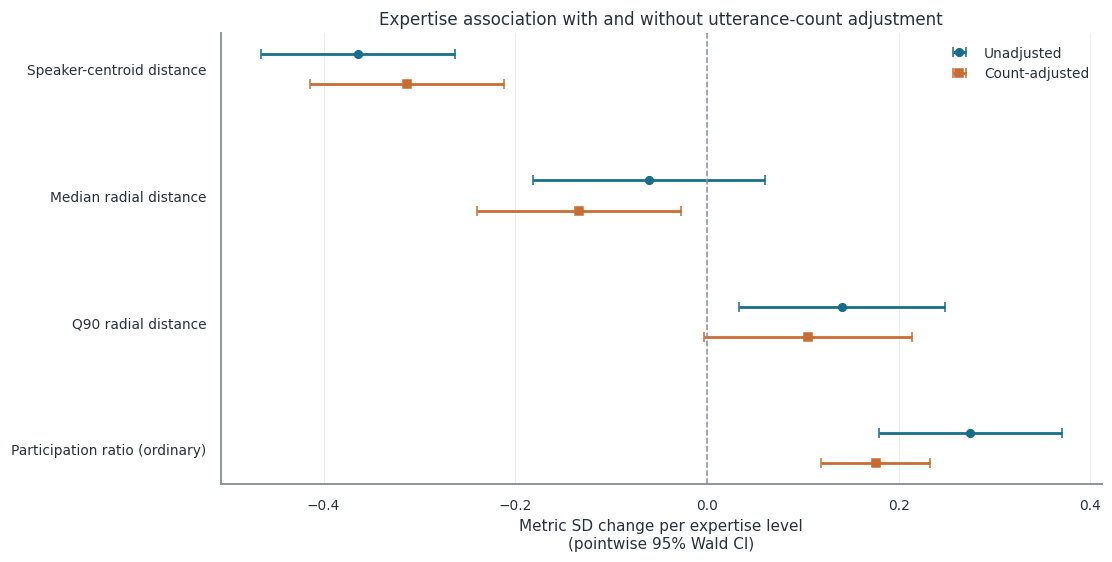

In [6]:
results["p_fdr_bh_8"] = multipletests(results["p_bootstrap"], method="fdr_bh")[1]
results["p_holm_8"] = multipletests(results["p_bootstrap"], method="holm")[1]
results["passes_fdr_05"] = results["p_fdr_bh_8"] < ALPHA
report_columns = ["label", "adjustment", "n_conversations", "n_videos", "beta_raw", "ci_low_raw", "ci_high_raw",
                  "expert_minus_child_raw", "p_bootstrap", "p_bootstrap_mcse", "p_fdr_bh_8", "p_holm_8"]
display(results[report_columns].round(5))
print("CI: approximate pointwise REML Wald; p-value: ML parametric bootstrap; FDR family: all 8 tests.")

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
for adjustment, offset in [("Unadjusted", -0.12), ("Count-adjusted", 0.12)]:
    color = MODEL_COLORS[adjustment]
    subset = results[results.adjustment.eq(adjustment)].set_index("metric").loc[list(METRICS)]
    ax.errorbar(subset.beta_sd, np.arange(4)+offset,
                xerr=np.vstack([subset.beta_sd-subset.ci_low_sd, subset.ci_high_sd-subset.beta_sd]),
                fmt=MODEL_MARKERS[adjustment], capsize=3, color=color, label=adjustment)
ax.axvline(0, color=NEUTRAL, linestyle="--", linewidth=1)
ax.set(yticks=np.arange(4), yticklabels=list(METRIC_LABELS.values()),
       xlabel="Metric SD change per expertise level\n(pointwise 95% Wald CI)",
       title="Expertise association with and without utterance-count adjustment")
ax.invert_yaxis()
ax.legend()
ax.grid(axis="y", visible=False)
save_figure(fig, OUTPUT_DIR / "expertise_effects.png")
plt.show()

## Residual diagnostics

Inspect every model for curvature, unequal residual spread, extreme observations, and substantial departures from Gaussian residuals. These are conditional residuals after the estimated video intercept. The plots are diagnostics, not automatic pass/fail normality tests. If assumptions look poor, reassess the outcome transformation or covariance structure before interpreting p-values. The descriptive trajectories above also show whether a common linear expertise slope is plausible; random slopes or categorical expertise are follow-up sensitivity analyses, outside these eight primary fits.

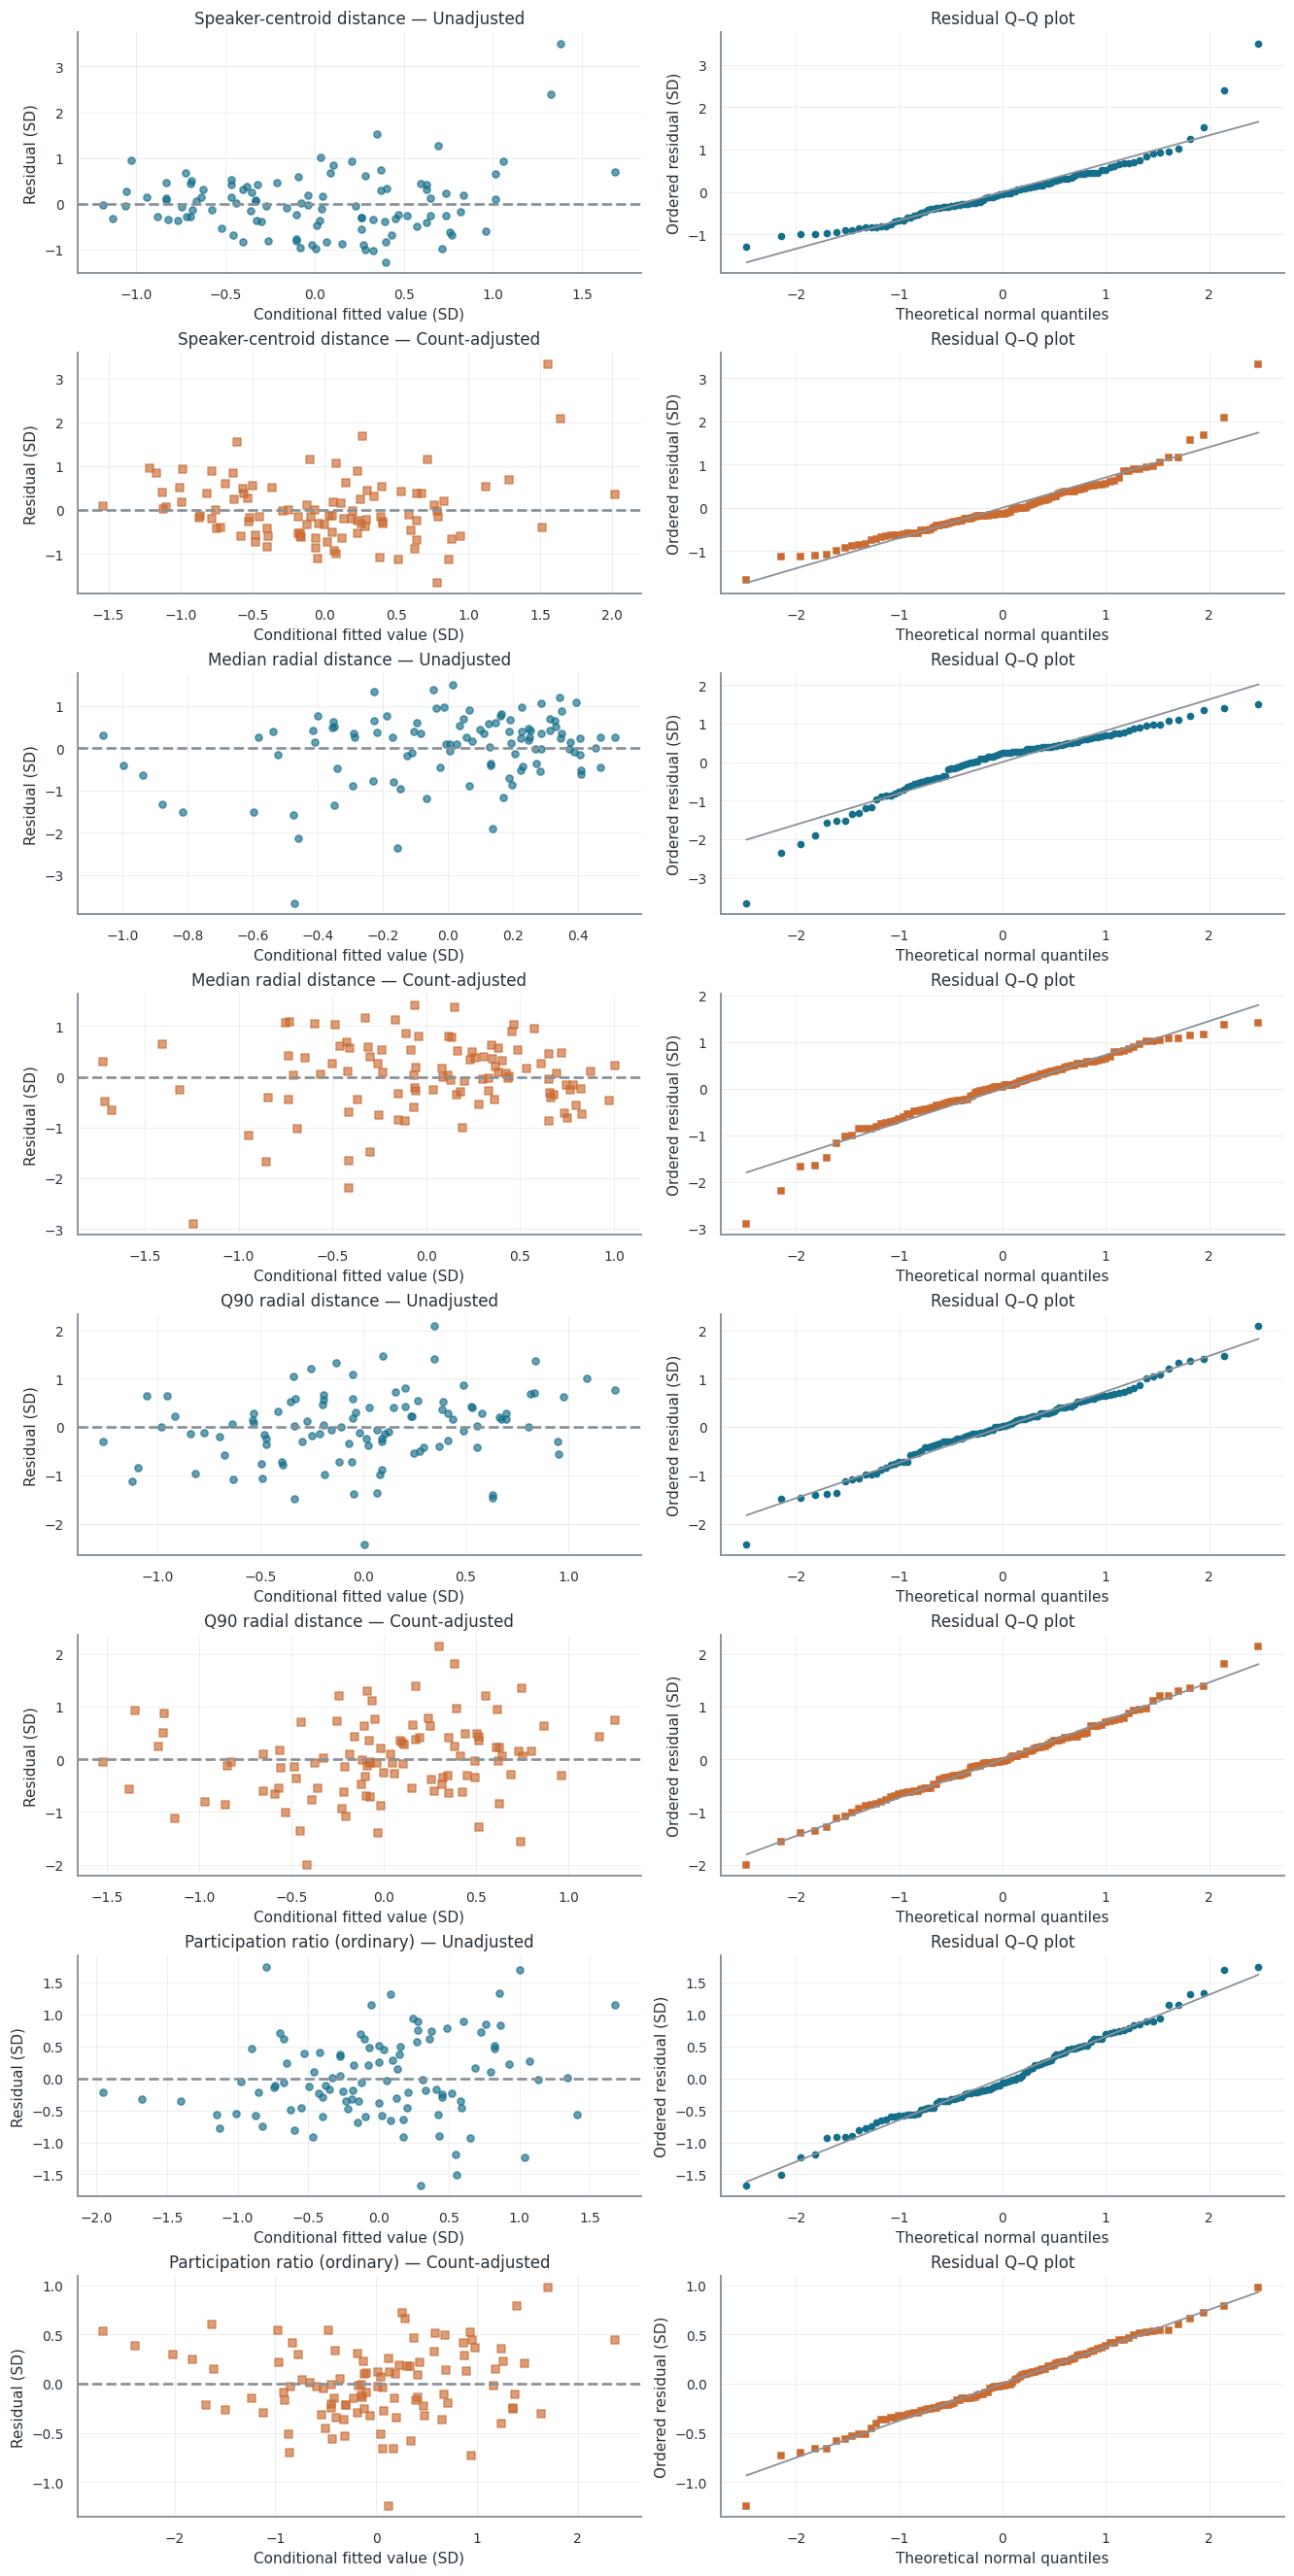

In [7]:
fig, axes = plt.subplots(len(results), 2, figsize=(12, 3*len(results)), constrained_layout=True)
for i, row in results.iterrows():
    fit = fits[(row.metric, row.adjustment)]
    frame = frames[row.metric]
    fixed_prediction = np.asarray(fit.model.exog @ fit.fe_params)
    marginal_residual = frame["outcome_z"].to_numpy() - fixed_prediction
    tau2 = float(np.asarray(fit.cov_re)[0, 0])
    # BLUP formula also works at tau² = 0, where result.resid can fail in statsmodels.
    offsets = (tau2 / (fit.scale + group_sizes*tau2)) * (Z.T @ marginal_residual)
    fitted = fixed_prediction + offsets[group_codes]
    residual = frame["outcome_z"].to_numpy() - fitted
    axes[i, 0].scatter(fitted, residual, alpha=0.65, s=22, color=MODEL_COLORS[row.adjustment], marker=MODEL_MARKERS[row.adjustment])
    axes[i, 0].axhline(0, color=NEUTRAL, linestyle="--")
    axes[i, 0].set(xlabel="Conditional fitted value (SD)", ylabel="Residual (SD)",
                   title=f"{METRIC_LABELS[row.metric]} — {row.adjustment}")
    stats.probplot(residual, dist="norm", plot=axes[i, 1])
    points, reference = axes[i, 1].get_lines()
    points.set(color=MODEL_COLORS[row.adjustment], marker=MODEL_MARKERS[row.adjustment], markersize=4)
    reference.set(color=NEUTRAL, linewidth=1.2)
    axes[i, 1].set(title="Residual Q–Q plot", xlabel="Theoretical normal quantiles", ylabel="Ordered residual (SD)")
save_figure(fig, OUTPUT_DIR / "residual_diagnostics.png")
plt.show()

### Historical diagnostic observations (before reorganization)

On the current 105-conversation export, speaker-centroid residuals show a pronounced upper tail, and median radial residuals show a pronounced lower tail and some uneven spread. Q90 and PR residuals look closer to the Gaussian reference. Therefore, treat the Gaussian-bootstrap significance results for centroid and median radial distance as provisional pending an influence/robustness check; the bootstrap reproduces the fitted Gaussian assumptions rather than removing these departures. No observations were removed on the basis of these plots. Reassess this note if the source data change.

## Save reproducible results

The manifest records the source hash, metric definitions, package versions, random seed and bootstrap settings. Existing source notebooks and source CSVs are not modified. Re-running this notebook replaces only its dedicated output files.

For publication, increase bootstrap replicates when Monte Carlo uncertainty could affect the conclusion, inspect diagnostics, verify that the paper uses these exact metric variants and sample, and describe these analyses as exploratory. Count adjustment does not eliminate all sample-size bias or distinguish expertise from age, production/editing decisions, and other differences between partner groups.

In [8]:
results.to_csv(OUTPUT_DIR / "mixed_model_results.csv", index=False)
results[report_columns].to_csv(OUTPUT_DIR / "paper_results_table.csv", index=False)
pd.concat(bootstrap_draws, ignore_index=True).to_csv(OUTPUT_DIR / "bootstrap_null_statistics.csv", index=False)
summary_text = "\n\n".join(f"{metric} | {adjustment}\n{fit.summary()}" for (metric, adjustment), fit in fits.items())
(OUTPUT_DIR / "model_summaries.txt").write_text(summary_text)
manifest = {
    "source": str(SOURCE.relative_to(PROJECT_ROOT)),
    "source_sha256": hashlib.sha256(SOURCE.read_bytes()).hexdigest(),
    "metrics": METRICS, "pr_variant": "ordinary centered-covariance PR, not bias-corrected",
    "centroid_selection": "n_words >= 5; count covariate is total nonempty utterances",
    "radial_variant": "full pooled centroid, not leave-one-out",
    "n_conversations": len(data), "n_videos": data.video_group.nunique(),
    "seed": SEED, "bootstrap_replicates_per_test": N_BOOTSTRAP,
    "estimation": "REML coefficients and pointwise Wald CIs; ML parametric-bootstrap LRT p-values",
    "multiplicity_family": "all eight expertise tests; BH and Holm",
    "packages": {p: importlib.metadata.version(p) for p in ["numpy", "pandas", "scipy", "statsmodels", "matplotlib"]},
}
(OUTPUT_DIR / "analysis_manifest.json").write_text(json.dumps(manifest, indent=2))
print("Saved results to:", OUTPUT_DIR)
print("Interpretation table:", OUTPUT_DIR / "paper_results_table.csv")

Saved results to: /Users/yume/PycharmProjects/horizons_2/outputs/paper/statistical_significance
Interpretation table: /Users/yume/PycharmProjects/horizons_2/outputs/paper/statistical_significance/paper_results_table.csv
